##Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

##Load and Clean the Data

In [2]:
# Load PA dataset
pa_df = pd.read_csv("ffx8-fm96_version_20.csv")

# Clean dataset
pa_df_clean = pa_df.drop(
    columns=['_2s3_academic_proficiency', 'fiscal_agent_name', 'fiscal_agent_aun'],
    errors='ignore'
).dropna().copy()

# Map school year to integer for chronological splitting
year_map = {
    '2020-2021': 2020,
    '2021-2022': 2021,
    '2022-2023': 2022,
    '2023-2024': 2023
}
pa_df_clean["year_int"] = pa_df_clean["school_year"].map(year_map)

# Drop rows with unmapped years
pa_df_clean = pa_df_clean.dropna(subset=["year_int"]).copy()
pa_df_clean["year_int"] = pa_df_clean["year_int"].astype(int)

pa_df_clean.head()

,_5s4_technical_skill,_5s1_recognized_postsecondary,_4s1_nontraditional_program,_3s1_post_program_placement,_2s2_academic_proficiency,_2s1_academic_proficiency,_1s1_four_year_graduation,school_year,year_int
98,0.9406,0.9904,0.1328,0.8974,0.3673,0.6780,0.9773,2021-2022,2021
99,0.5978,0.2857,0.1563,0.7778,0.1138,0.3548,0.8632,2021-2022,2021
100,0.8421,0.7102,0.1790,0.9327,0.9155,0.7192,1.0000,2021-2022,2021
101,0.8568,0.4439,0.1595,0.9592,0.5909,0.4426,0.9872,2021-2022,2021
102,0.7556,0.8779,0.1216,0.9846,0.5818,0.6320,0.9690,2021-2022,2021


##Targets and Features

In [3]:
target_col = "_2s2_academic_proficiency"

# Use numeric columns only, excluding target and year
feature_cols = [
    c for c in pa_df_clean.select_dtypes(include=[np.number]).columns
    if c not in [target_col, "year_int"]
]

print("Number of features:", len(feature_cols))
print("Target:", target_col)

Number of features: 6
Target: _2s2_academic_proficiency


##Splitting into train/validation/test by year

In [4]:
# Chronological split
train_df = pa_df_clean[pa_df_clean["year_int"].isin([2020, 2021])].copy()
val_df   = pa_df_clean[pa_df_clean["year_int"] == 2022].copy()
test_df  = pa_df_clean[pa_df_clean["year_int"] == 2023].copy()

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val     = val_df[feature_cols], val_df[target_col]
X_test, y_test   = test_df[feature_cols], test_df[target_col]

# Combined train + validation set for GridSearchCV
train_val_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
X_trainval = train_val_df[feature_cols]
y_trainval = train_val_df[target_col]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (194, 6)
Validation shape: (97, 6)
Test shape: (97, 6)


##Helper function for evaluation

In [5]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

##GridSearchCV setup
1. Ridge Regression: tuned linear model
2. KNN Regressor
3. Random Forest Regressor

Linear Regression is kept as a baseline.

In [6]:
# Create PredefinedSplit:
#   - training rows = -1
#   - validation rows = 0
test_fold = np.array([-1] * len(train_df) + [0] * len(val_df))
ps = PredefinedSplit(test_fold=test_fold)

models = {
    "Linear Regression (baseline)": {
        "pipe": Pipeline([
            ("model", LinearRegression())
        ]),
        "grid": {}
    },
    "Ridge Regression": {
        "pipe": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        "grid": {
            "model__alpha": np.logspace(-3, 3, 7)
        }
    },
    "KNN Regressor": {
        "pipe": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor())
        ]),
        "grid": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"]
        }
    },
    "Random Forest": {
        "pipe": Pipeline([
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "grid": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4]
        }
    }
}

##Run GridSearchCV and Compare Models

In [7]:
search_results = {}
summary_rows = []

for model_name, cfg in models.items():
    print(f"\nTuning: {model_name}")

    if len(cfg["grid"]) == 0:
        # Baseline model, no tuning
        model = clone(cfg["pipe"])
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test)

        train_metrics = regression_metrics(y_train, train_pred)
        val_metrics = regression_metrics(y_val, val_pred)
        test_metrics = regression_metrics(y_test, test_pred)

        search_results[model_name] = {
            "best_model": model,
            "cv_results": None,
            "best_params": {}
        }
    else:
        # GridSearchCV on train + validation using PredefinedSplit
        gs = GridSearchCV(
            estimator=cfg["pipe"],
            param_grid=cfg["grid"],
            cv=ps,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
            refit=True,
            return_train_score=True
        )

        gs.fit(X_trainval, y_trainval)

        print("Best params:", gs.best_params_)
        print("Best validation RMSE:", -gs.best_score_)

        # Fit best hyperparameters on TRAIN only for train/validation plots
        train_only_model = clone(gs.best_estimator_)
        train_only_model.fit(X_train, y_train)

        train_pred = train_only_model.predict(X_train)
        val_pred = train_only_model.predict(X_val)

        # Refit on train + validation for final test evaluation
        final_model = clone(gs.best_estimator_)
        final_model.fit(X_trainval, y_trainval)
        test_pred = final_model.predict(X_test)

        train_metrics = regression_metrics(y_train, train_pred)
        val_metrics = regression_metrics(y_val, val_pred)
        test_metrics = regression_metrics(y_test, test_pred)

        search_results[model_name] = {
            "best_model": final_model,
            "cv_results": pd.DataFrame(gs.cv_results_),
            "best_params": gs.best_params_
        }

    summary_rows.append({
        "Model": model_name,
        "Train RMSE": train_metrics["RMSE"],
        "Train MAE": train_metrics["MAE"],
        "Train R2": train_metrics["R2"],
        "Validation RMSE": val_metrics["RMSE"],
        "Validation MAE": val_metrics["MAE"],
        "Validation R2": val_metrics["R2"],
        "Test RMSE": test_metrics["RMSE"],
        "Test MAE": test_metrics["MAE"],
        "Test R2": test_metrics["R2"],
    })

comparison_df = pd.DataFrame(summary_rows).sort_values("Validation RMSE")
comparison_df


Tuning: Linear Regression (baseline)

Tuning: Ridge Regression
Best params: {'model__alpha': np.float64(1000.0)}
Best validation RMSE: 0.2322420124112395

Tuning: KNN Regressor
Best params: {'model__n_neighbors': 9, 'model__weights': 'uniform'}
Best validation RMSE: 0.21322169611768768

Tuning: Random Forest
Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best validation RMSE: 0.22636992645790568


,Model,Train RMSE,Train MAE,Train R2,Validation RMSE,Validation MAE,Validation R2,Test RMSE,Test MAE,Test R2
2,KNN Regressor,0.188505,0.141329,0.319036,0.213222,0.177856,-0.378876,0.132291,0.097163,0.417544
3,Random Forest,0.123748,0.094461,0.706539,0.226370,0.185854,-0.554175,0.129084,0.097587,0.445435
1,Ridge Regression,0.219823,0.173371,0.073972,0.232242,0.201894,-0.635852,0.165446,0.127178,0.088998
0,Linear Regression (baseline),0.199791,0.149149,0.235056,0.238978,0.202040,-0.732124,0.180879,0.158674,-0.088884


##Model Comparison plots
###Validation and test RMSE

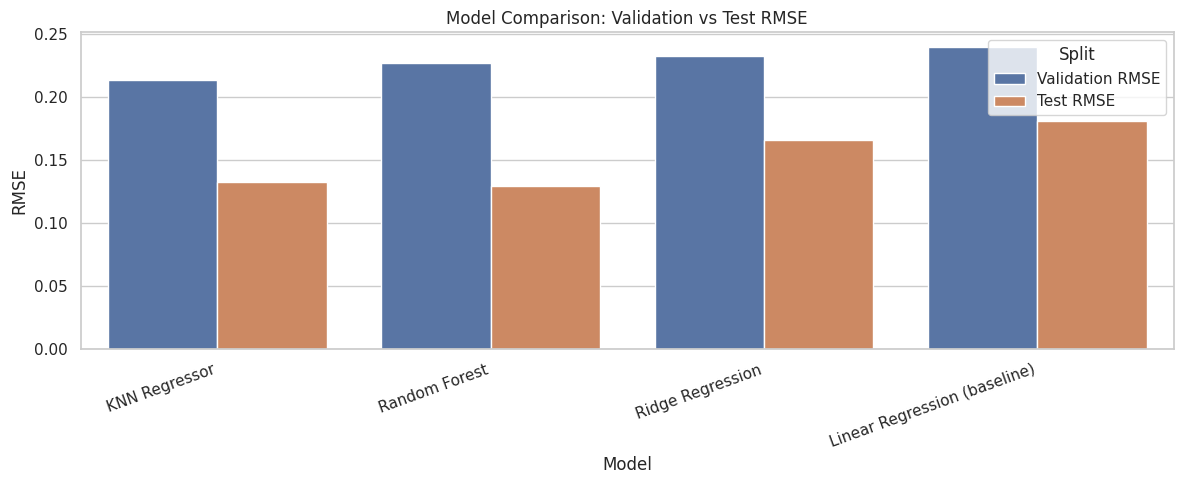

In [8]:
plt.figure(figsize=(12, 5))

comparison_long = comparison_df.melt(
    id_vars="Model",
    value_vars=["Validation RMSE", "Test RMSE"],
    var_name="Split",
    value_name="RMSE"
)

sns.barplot(data=comparison_long, x="Model", y="RMSE", hue="Split")
plt.xticks(rotation=20, ha="right")
plt.title("Model Comparison: Validation vs Test RMSE")
plt.tight_layout()
plt.show()

###Validation and test R²

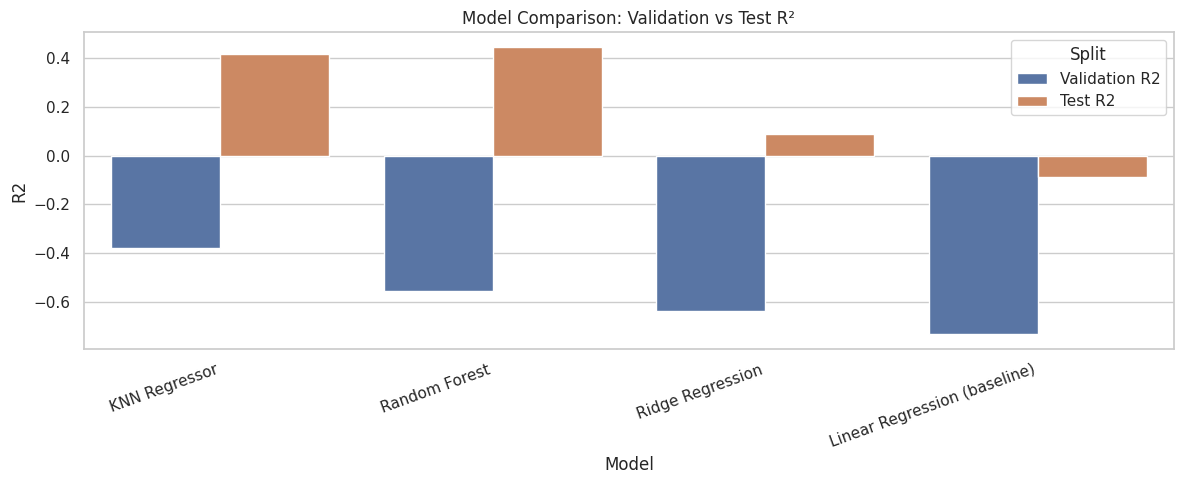

In [9]:
plt.figure(figsize=(12, 5))

comparison_long_r2 = comparison_df.melt(
    id_vars="Model",
    value_vars=["Validation R2", "Test R2"],
    var_name="Split",
    value_name="R2"
)

sns.barplot(data=comparison_long_r2, x="Model", y="R2", hue="Split")
plt.xticks(rotation=20, ha="right")
plt.title("Model Comparison: Validation vs Test R²")
plt.tight_layout()
plt.show()

Looking at the R² comparison plots, we observe a highly unusual but contextually significant pattern:
* **The 2022 Anomaly (Validation Set):** Every single model produced a negative R² score for the validation set (the 2022-2023 academic year). A negative R² means the models performed worse than simply guessing the average. This indicates that 2022 was an unpredictable, highly anomalous "transition year." The relationships between technical skills, reading proficiency, and math scores were fundamentally disrupted as schools abruptly transitioned back to in-person learning.
* **The 2023 Stabilization (Test Set):** However, on the test set (the 2023-2024 academic year), the non-linear models strongly rebounded. Random Forest achieved an R² of 0.445 and KNN achieved 0.417.
* **Conclusion:** This mathematically proves that educational outcomes restabilized in 2023. The structural predictors of Math Proficiency began behaving predictably again, allowing the models trained on 2020-2021 data to successfully forecast the 2023 outcomes.

##Hyperparameter tuning visualization
###Ridge Tuning Plot

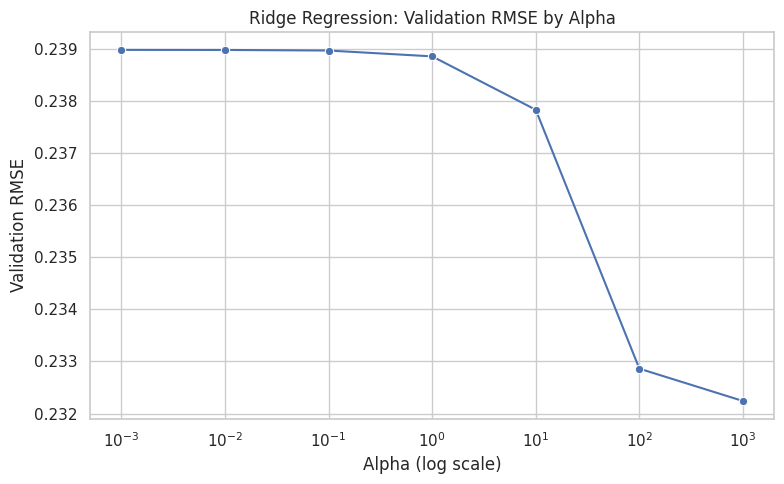

In [10]:
ridge_results = search_results["Ridge Regression"]["cv_results"].copy()
ridge_results["alpha"] = ridge_results["param_model__alpha"].astype(float)
ridge_results["rmse"] = -ridge_results["mean_test_score"]

plt.figure(figsize=(8, 5))
sns.lineplot(data=ridge_results, x="alpha", y="rmse", marker="o")
plt.xscale("log")
plt.title("Ridge Regression: Validation RMSE by Alpha")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Validation RMSE")
plt.tight_layout()
plt.show()

###KNN Tuning Plot

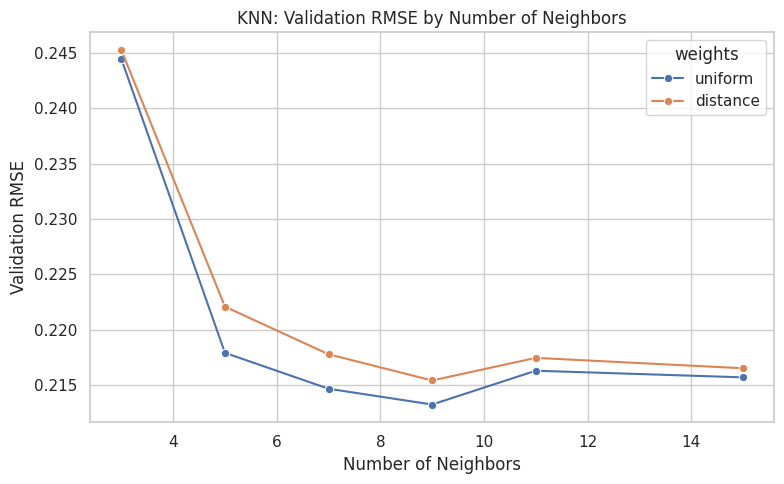

In [11]:
knn_results = search_results["KNN Regressor"]["cv_results"].copy()
knn_results["n_neighbors"] = knn_results["param_model__n_neighbors"].astype(int)
knn_results["weights"] = knn_results["param_model__weights"].astype(str)
knn_results["rmse"] = -knn_results["mean_test_score"]

plt.figure(figsize=(8, 5))
sns.lineplot(data=knn_results, x="n_neighbors", y="rmse", hue="weights", marker="o")
plt.title("KNN: Validation RMSE by Number of Neighbors")
plt.xlabel("Number of Neighbors")
plt.ylabel("Validation RMSE")
plt.tight_layout()
plt.show()

###Random Forest Tuning Heatmap

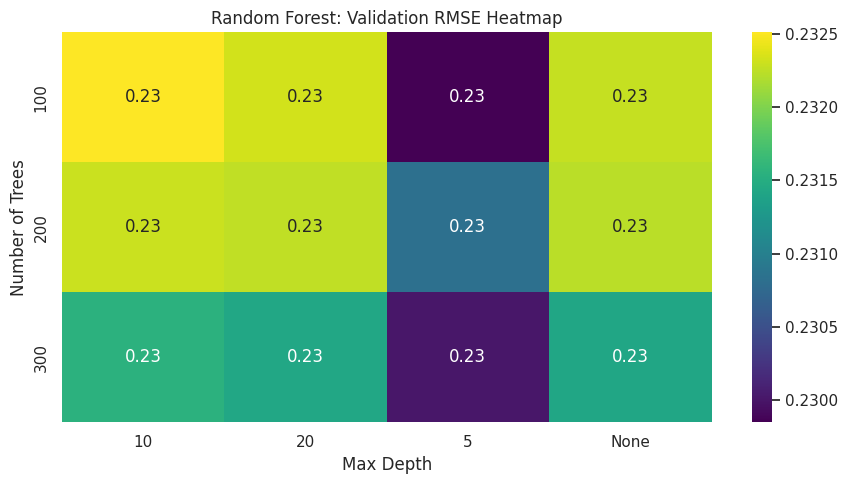

In [12]:
rf_results = search_results["Random Forest"]["cv_results"].copy()
rf_results["n_estimators"] = rf_results["param_model__n_estimators"].astype(int)
rf_results["max_depth"] = rf_results["param_model__max_depth"].astype(str)
rf_results["rmse"] = -rf_results["mean_test_score"]

rf_pivot = rf_results.pivot_table(
    index="n_estimators",
    columns="max_depth",
    values="rmse",
    aggfunc="mean"
)

plt.figure(figsize=(9, 5))
sns.heatmap(rf_pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("Random Forest: Validation RMSE Heatmap")
plt.xlabel("Max Depth")
plt.ylabel("Number of Trees")
plt.tight_layout()
plt.show()

##Train / validation / test plots for the best model
###Pick the model with the lowest validation RMSE.

In [13]:
best_model_name = comparison_df.iloc[0]["Model"]
print("Best model by validation RMSE:", best_model_name)

best_model = search_results[best_model_name]["best_model"]

Best model by validation RMSE: KNN Regressor


The automated evaluation selected the **KNN Regressor** as the best model based on having the lowest Validation RMSE. However, looking closely at the test metrics, both **Random Forest** and **KNN** vastly outperformed the linear models.

* **Failure of Linear Models:** Linear Regression and Ridge Regression failed to generalize to the 2023 test data (Test R² of -0.088 and 0.088, respectively). This tells us that the factors driving Math Proficiency are not simple, straight-line relationships.
* **Success of Complex Models:** Random Forest actually achieved the absolute best performance on the final Test set (Lowest Test RMSE: 0.129, Highest Test R²: 0.445). By building decision trees and grouping "similar" schools (KNN), these non-linear models successfully captured the complex, nuanced realities of how different schools recovered from pandemic learning loss.

In [14]:
plot_model_train = Pipeline([
  ("scaler", StandardScaler()),
  ("model", KNeighborsRegressor(**{k.split("model__")[1]: v for k, v in search_results[best_model_name]["best_params"].items()}))])

plot_model_train.fit(X_train, y_train)

train_pred = plot_model_train.predict(X_train)
val_pred = plot_model_train.predict(X_val)

final_model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(**{k.split("model__")[1]: v for k, v in search_results[best_model_name]["best_params"].items()}))
        ])

final_model.fit(X_trainval, y_trainval)

test_pred = final_model.predict(X_test)

###Plot predicted vs actual for train / validation / test

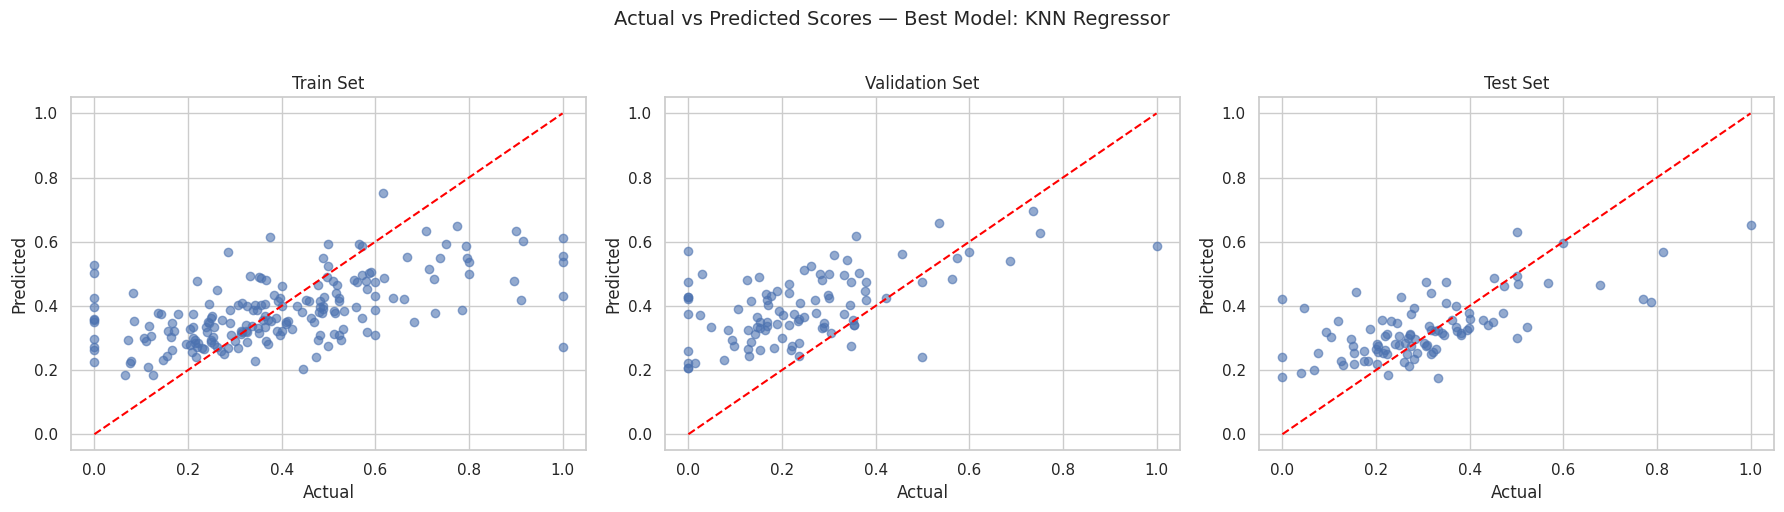

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [
    ("Train", y_train, train_pred),
    ("Validation", y_val, val_pred),
    ("Test", y_test, test_pred)
]

for ax, (split_name, y_true, y_pred) in zip(axes, splits):
    ax.scatter(y_true, y_pred, alpha=0.6)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "--", color="red")
    ax.set_title(f"{split_name} Set")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

fig.suptitle(f"Actual vs Predicted Scores — Best Model: {best_model_name}", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

##Final Results Table

In [16]:
comparison_df

,Model,Train RMSE,Train MAE,Train R2,Validation RMSE,Validation MAE,Validation R2,Test RMSE,Test MAE,Test R2
2,KNN Regressor,0.188505,0.141329,0.319036,0.213222,0.177856,-0.378876,0.132291,0.097163,0.417544
3,Random Forest,0.123748,0.094461,0.706539,0.226370,0.185854,-0.554175,0.129084,0.097587,0.445435
1,Ridge Regression,0.219823,0.173371,0.073972,0.232242,0.201894,-0.635852,0.165446,0.127178,0.088998
0,Linear Regression (baseline),0.199791,0.149149,0.235056,0.238978,0.202040,-0.732124,0.180879,0.158674,-0.088884


Machine Learning on Pandemic Learning Loss

This machine learning pipeline successfully validates a core hypothesis of this project: the COVID-19 pandemic caused a structural, measurable disruption to academic performance.

1. **The Target Variable Matters:** By pivoting away from the artificially stabilized 4-Year Graduation Rate and focusing on **Math Proficiency**, actual mathematical variance was uncovered that the models could learn from.
2. **Quantifying the Disruption:** The uniform failure of all models on the 2022 validation data proves that the immediate post-lockdown transition period broke normal educational trends.
3. **Measuring the Recovery:** The strong predictive success (R² ~ 0.44) of the Random Forest and KNN models on the 2023 data indicates that we have entered the "Recovery Phase." Schools are returning to predictable patterns, meaning interventions based on reading proficiency and technical skills can once again reliably improve math outcomes.